In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


In [46]:
import pandas as pd
import statistics as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

In [48]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [50]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [51]:
#the time column works on seconds since first transaction 
#lets change this into a 24h clock to see if we can find a correlation

df['Time_of_day'] = df['Time'] / 3600 % 24

#lets also drop the original time column

df.drop(['Time'], axis=1)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Time_of_day
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.000000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.000000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.000278
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.000278
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.000556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.996111
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.996389
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.996667
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.996667


In [52]:
print(f"Average sum for each transaction = ${df['Amount'].mean():.2f}")
print(f"Standard deviation = ${stats.stdev(df['Amount']):.2f}")


Average sum for each transaction = $88.35
Standard deviation = $250.12


<Axes: >

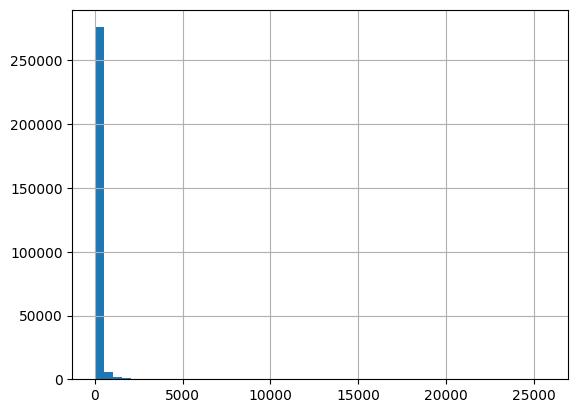

In [53]:
df['Amount'].hist(bins=50)

In [54]:
print(f"Number of fraudulent transactions = {(df['Class'] == 1).sum():.2f}")
print(f"Percentage of fraudulent transactions = {((df['Class'] == 1).sum()) / len(df) * 100:.2f}%")

Number of fraudulent transactions = 492.00
Percentage of fraudulent transactions = 0.17%


In [55]:
#Huge class imbalance. Lets if theres a correlation with amount.
print(df.groupby('Class')['Amount'].describe())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


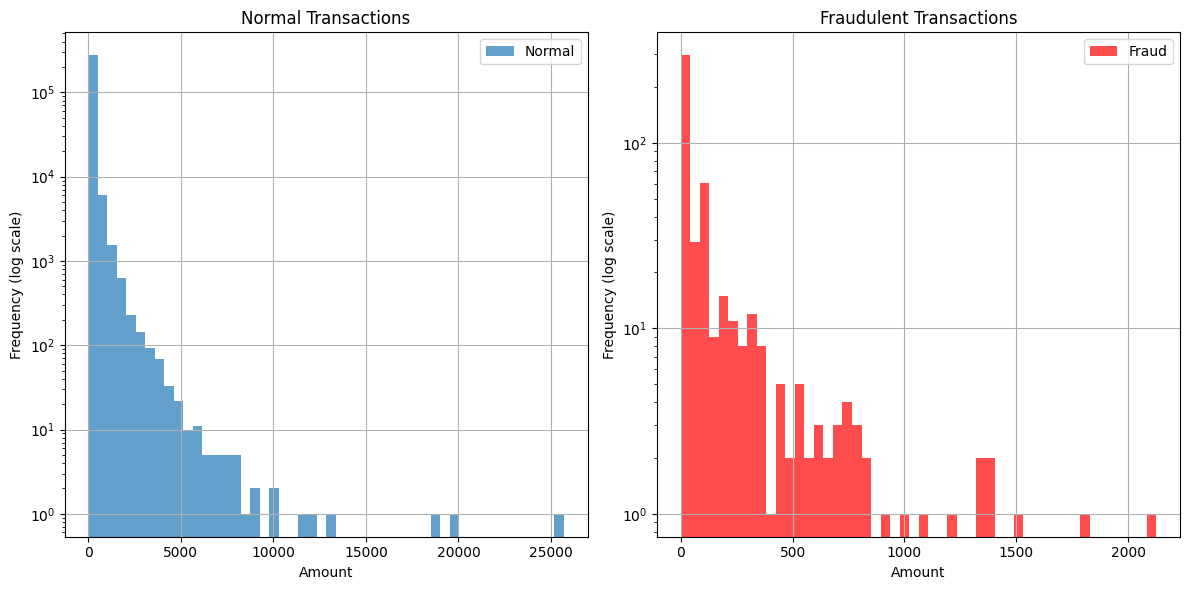

In [56]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.7, label='Normal')
plt.xlabel('Amount')
plt.ylabel('Frequency (log scale)')
plt.yscale('log')
plt.title('Normal Transactions')
plt.legend()

plt.subplot(1, 2, 2)
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.7, label='Fraud', color='red')
plt.xlabel('Amount')
plt.ylabel('Frequency (log scale)')
plt.yscale('log')
plt.title('Fraudulent Transactions')
plt.legend()

plt.tight_layout()
plt.show()

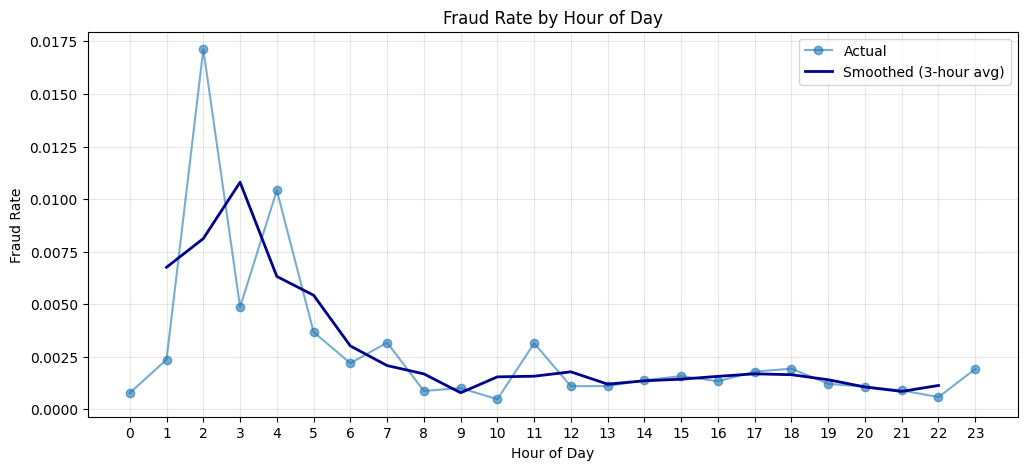

In [57]:


fraud_by_hour = df.groupby(df['Time_of_day'].astype(int))['Class'].mean()

smoothed = fraud_by_hour.rolling(window=3, center=True).mean()

plt.figure(figsize=(12, 5))
fraud_by_hour.plot(kind='line', marker='o', label='Actual', alpha=0.6)
smoothed.plot(kind='line', linewidth=2, label='Smoothed (3-hour avg)', color='darkblue')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

looks like a lot of the transactions that are happening in the early hours of the morning are fraudulent. lets see if this is consistent with non-fraud transactions


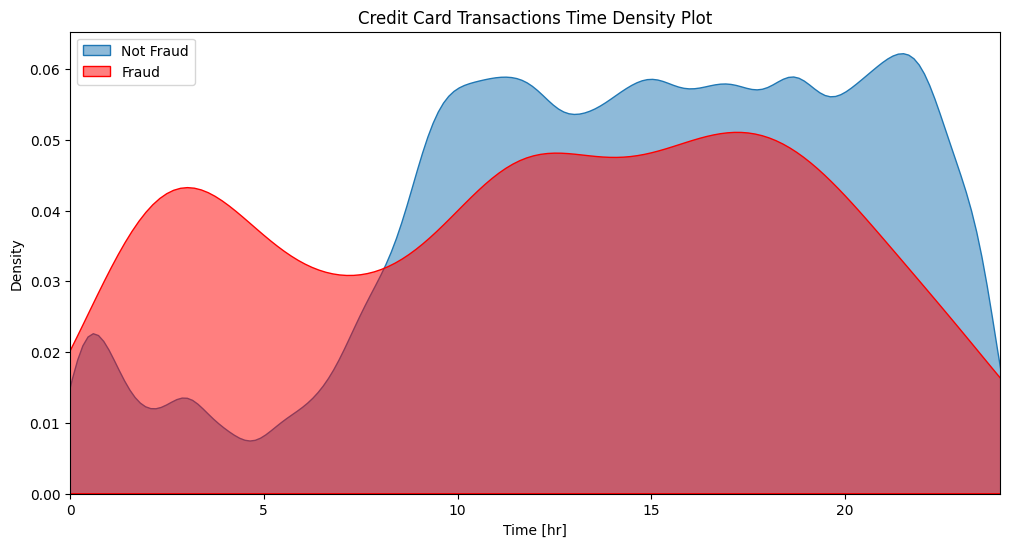

In [58]:
class_0 = df.loc[df['Class'] == 0]["Time_of_day"]
class_1 = df.loc[df['Class'] == 1]["Time_of_day"]

plt.figure(figsize=(12, 6))
sns.kdeplot(class_0, label='Not Fraud', fill=True, alpha=0.5)
sns.kdeplot(class_1, label='Fraud', fill=True, alpha=0.5, color='red')
plt.title('Credit Card Transactions Time Density Plot')
plt.xlabel('Time [hr]')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 24)
plt.show()

The normal transactions follow the pattern we would expect, quieting down in the early hours, however fraudulent transactions seem to be spread fairly evenly through all hours of the day

Finally we can check the heatmap. Thiswill be pretty useless given the full data set, so we first select a random subsample, the same size as the fraudulent data, and then we can plot the heatmap based off this subsample

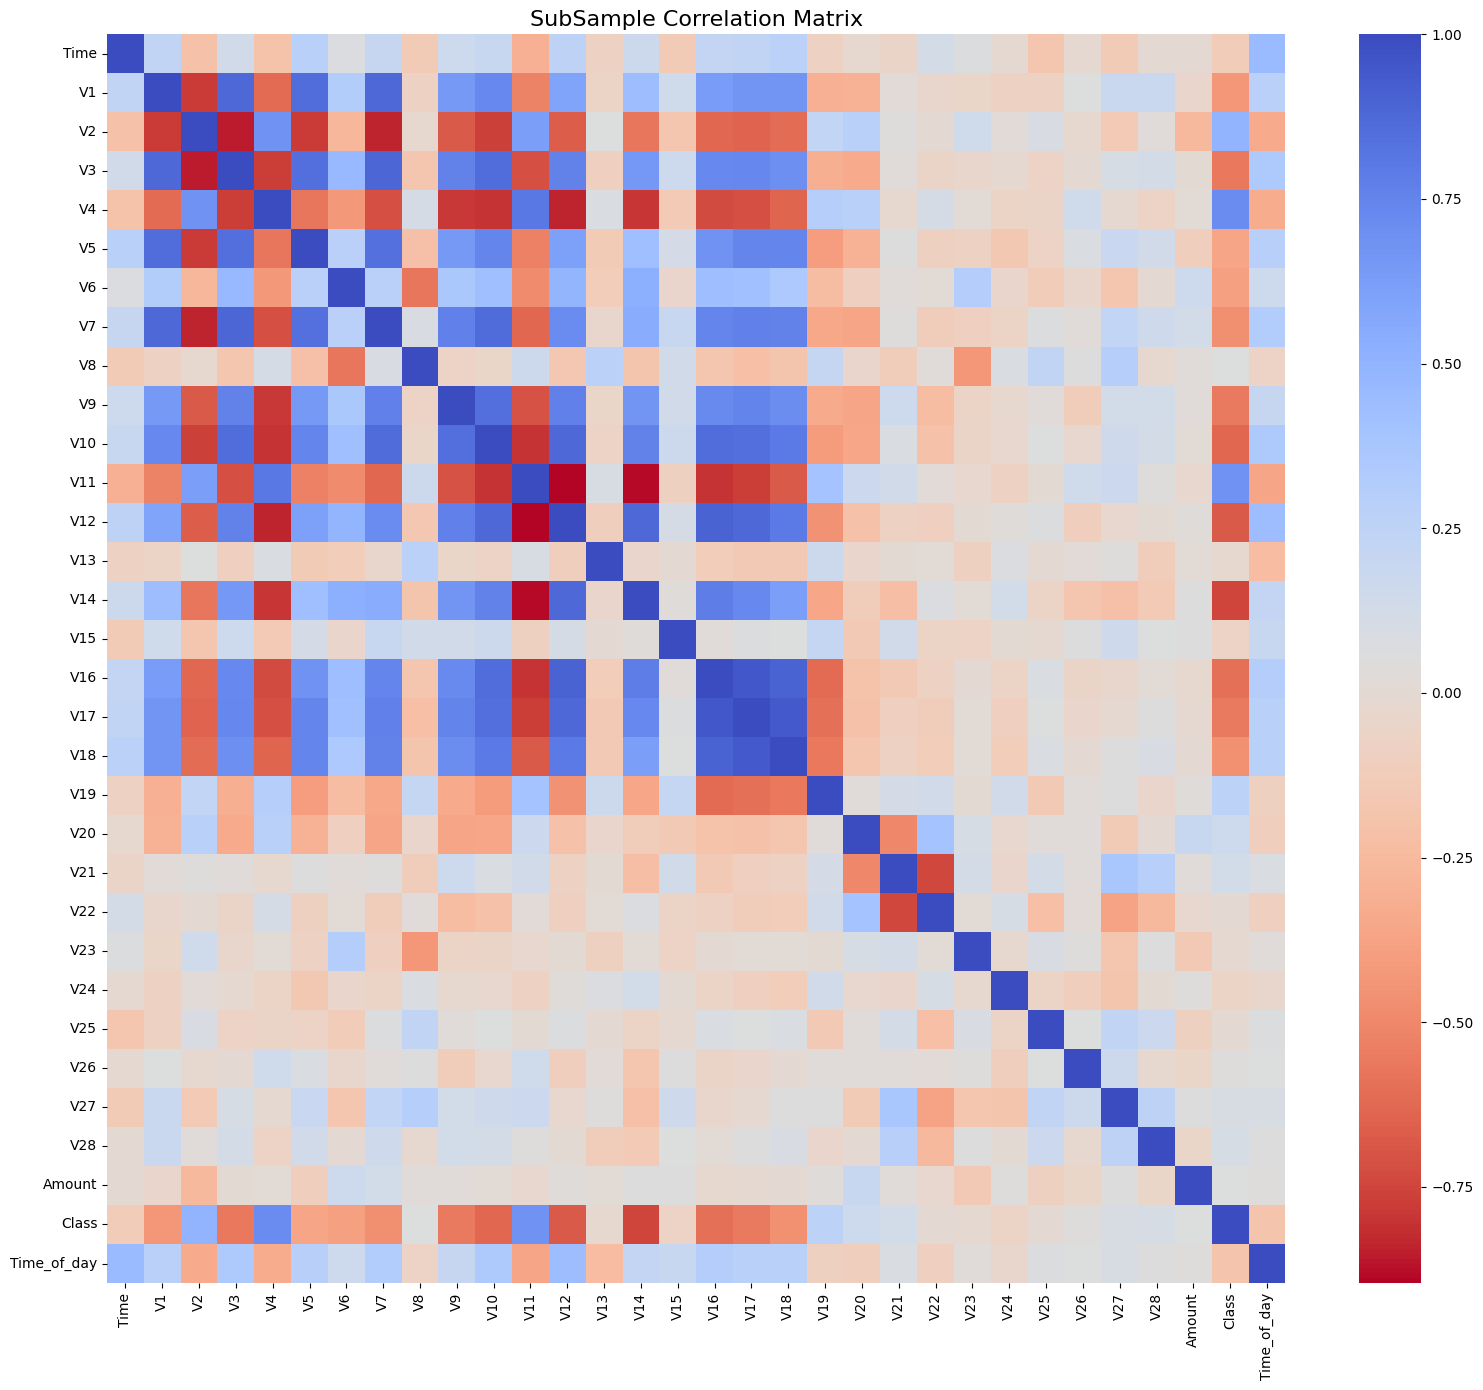

In [59]:
df = df.sample(frac=1)
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]
normal_distributed_df = pd.concat([fraud_df, non_fraud_df])
new_df = normal_distributed_df.sample(frac=1, random_state=42)

# Plot subsample heatmap
plt.figure(figsize=(16, 14))
sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot=False, cbar=True)
plt.title('SubSample Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

Clearly some strong correlations with the anonymised features once the dataset has been balanced. Lets now split into train/val/test and then we can look at dealing with the class imbalance

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

X = df.drop('Class', axis=1)
y = df['Class']

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

# Get the train and test indices
for train_index, test_index in sss.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Verify the split preserved class ratios
print(f"Training set fraud rate: {y_train.mean():.4f}")
print(f"Test set fraud rate: {y_test.mean():.4f}")
print(f"Original fraud rate: {y.mean():.4f}")

Training set fraud rate: 0.0017
Test set fraud rate: 0.0017
Original fraud rate: 0.0017


Now lets look at the addressing the class imbalance
Due to the severity of the imbalance, undersampling will mean throwing away an enormous amount data, and potentially underfitting the data
Oversampling will involve creating thousands of new, identical fraud cases and overfitting the data.
First I will use SMOTE to try to reduce the overfitting

In [61]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

All the data is numerical and scaled already, so we can go straight into training the model. Lets first try logistic regression

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

In [63]:
#LogReg = LogisticRegression(max_iter=100)
#LogReg.fit(X_resampled, y_resampled)

In [64]:
#print(classification_report(y_test, LogReg.predict(X_test)))

Absolutely god awful at picking up false negatives. Lets try some other models and see if they have a similar problem

In [65]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import collections

In [66]:
#classifiers = {
 #   "XGBoostClassifier": XGBClassifier(),
  #  "DecisionTreeClassifier": DecisionTreeClassifier(),
   # "KNearest": KNeighborsClassifier()
#}

from sklearn.model_selection import cross_val_score


for key, classifier in classifiers.items():
    classifier.fit(X_resampled, y_resampled)
    training_score = cross_val_score(classifier, X_resampled, y_resampled, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Confusion matrix", (classification_report(y_test, classifier.predict(X_test))))

Classifiers:  XGBClassifier Confusion matrix               
                precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.82      0.81       148

    accuracy                           1.00     85443
   macro avg       0.90      0.91      0.90     85443
weighted avg       1.00      1.00      1.00     85443

Classifiers:  DecisionTreeClassifier Confusion matrix            
                precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.43      0.78      0.56       148

    accuracy                           1.00     85443
   macro avg       0.72      0.89      0.78     85443
weighted avg       1.00      1.00      1.00     85443

Classifiers:  KNeighborsClassifier Confusion matrix               
                precision    recall  f1-score   support

           0       1.00      0.95      0.97     85295
           1       0.02      0.50      0.03       148

    accuracy                           0.95     85443
   macro avg       0.51      0.72      0.50     85443
weighted avg       1.00      0.95      0.97     85443

Deleted the codeblock and made it text instead because it takes flipping ages to run. \
Clearly XGBoost outperforms all of these models significantly so lets see if we can improve it anymore.


In [67]:
#Another technique for dealing with class imbalance is to use this scale position weight factor\
#This means the model penalizes mistakes in the fraud class more heavily than others, by a factor of the class imbalance

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

XGB_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc'
)
XGB_model.fit(X_train, y_train)
print(classification_report(y_test, XGB_model.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.78      0.80      0.79       148

    accuracy                           1.00     85443
   macro avg       0.89      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



This technique performs well but still slightly worse than SMOTE. Lets see if we can optimise this by messing around with threshold value and hyperparameters

In [79]:
smote = SMOTE(sampling_strategy=0.8)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Fraud ratio: {y_resampled.mean():.3f}")


model = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)
model.fit(X_resampled, y_resampled)

# Step 3: Optimize threshold for fraud F1
y_pred_proba = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores_fraud = []

for threshold in thresholds:
    y_pred_temp = (y_pred_proba >= threshold).astype(int)
    f1_fraud = f1_score(y_test, y_pred_temp, pos_label=1)
    f1_scores_fraud.append(f1_fraud)

optimal_threshold = thresholds[np.argmax(f1_scores_fraud)]
best_f1_fraud = max(f1_scores_fraud)

print(f"\nOptimal threshold: {optimal_threshold:.4f}")
print(f"Best F1 (fraud): {best_f1_fraud:.4f}")

# Step 4: Final predictions
y_pred_final = (y_pred_proba >= optimal_threshold).astype(int)
print("\nFinal Results:")
print(classification_report(y_test, y_pred_final, target_names=['Non-Fraud', 'Fraud']))

After SMOTE - Fraud ratio: 0.444

Optimal threshold: 0.8300
Best F1 (fraud): 0.8451

Final Results:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     85295
       Fraud       0.88      0.81      0.85       148

    accuracy                           1.00     85443
   macro avg       0.94      0.91      0.92     85443
weighted avg       1.00      1.00      1.00     85443



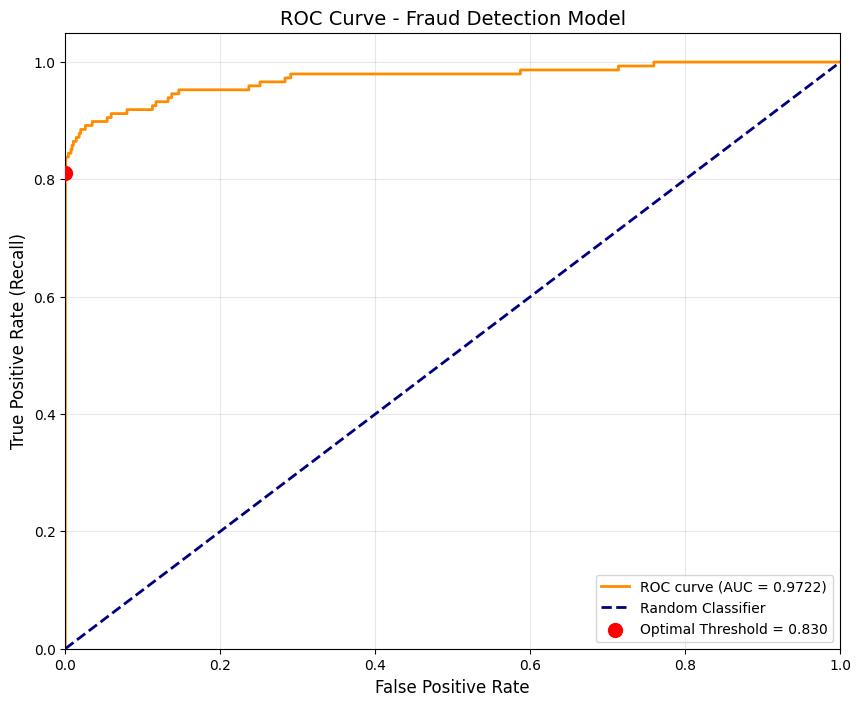

AUC-ROC Score: 0.9722


In [80]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

# Mark optimal threshold point
optimal_idx = np.argmin(np.abs(thresholds - optimal_threshold))
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, zorder=5, 
            label=f'Optimal Threshold = {optimal_threshold:.3f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Fraud Detection Model', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC-ROC Score: {roc_auc:.4f}")